# Grover's Search Algorithm — Qiskit Implementation

> **Course Project** | Quantum Computing  
> **Search space:** 10 qubits → 1024 states  
> **Marked states:** `0110011010` and `1101010001`

---

## Overview

Grover's algorithm provides a **quadratic speedup** for unstructured search problems.  
For a search space of $N$ items with $M$ marked elements, the optimal number of iterations is:

$$k \approx \frac{\pi}{4}\sqrt{\frac{N}{M}}$$

For our case: $N = 2^{10} = 1024$, $M = 2$

$$k \approx \frac{\pi}{4}\sqrt{\frac{1024}{2}} \approx 17.7 \approx 18 \text{ iterations}$$

## 0. Imports & Setup

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from matplotlib.patches import Patch
from qiskit import QuantumCircuit

# ── Project parameters ─────────────────────────────────────────
N_QUBITS = 10
TARGETS  = ["0110011010", "1101010001"]
SHOTS    = 2048

print(f"Search space : 2^{N_QUBITS} = {2**N_QUBITS} states")
print(f"Marked states: {TARGETS}")
print(f"Optimal iters: ~{int(round((np.pi/4)*np.sqrt(2**N_QUBITS/len(TARGETS))))}")

Search space : 2^10 = 1024 states
Marked states: ['0110011010', '1101010001']
Optimal iters: ~18


---

## 1. Oracle Construction

The oracle applies a **phase flip** ($|x\rangle \to -|x\rangle$) to each marked state.

**Strategy per target:**
1. Apply $X$ to every qubit whose target bit is `0` (so the MCZ fires on the right pattern).
2. Apply a multi-controlled-Z (MCZ) → flips phase of $|11\ldots1\rangle$.
3. Undo the $X$ gates (uncompute).

Oracle — depth: 8, gates: 26


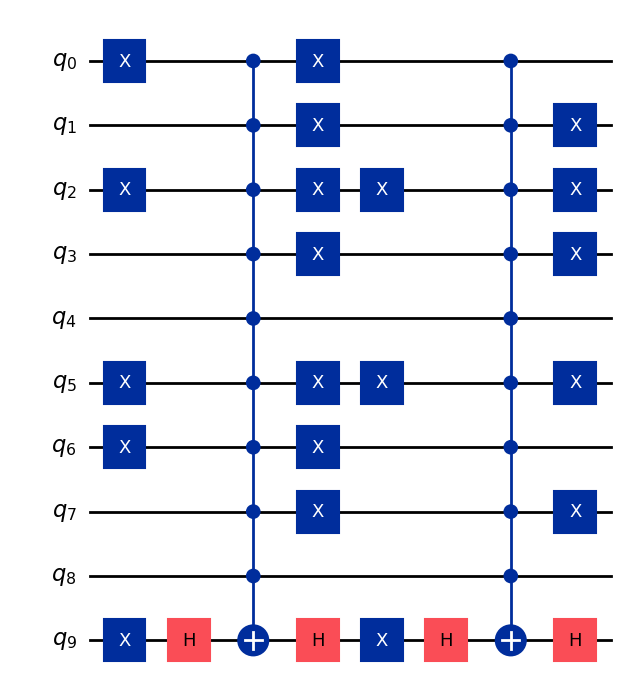

In [5]:
def build_oracle(n_qubits: int, targets: list) -> QuantumCircuit:
    """
    Phase-flip oracle for the given target bit strings.
    Works for any number of targets; changing `targets` automatically updates it.
    """
    qc = QuantumCircuit(n_qubits, name="Oracle")

    for target in targets:
        if len(target) != n_qubits:
            raise ValueError(f"Target '{target}' length != {n_qubits}")

        # X on '0' positions
        for i, bit in enumerate(reversed(target)):  # qubit 0 = LSB
            if bit == '0':
                qc.x(i)

        # MCZ decomposed as H · MCX · H on the last qubit
        controls = list(range(n_qubits - 1))
        tgt_q    = n_qubits - 1
        qc.h(tgt_q)
        qc.mcx(controls, tgt_q)
        qc.h(tgt_q)

        # Uncompute X gates
        for i, bit in enumerate(reversed(target)):
            if bit == '0':
                qc.x(i)

    return qc

# Preview the oracle
oracle = build_oracle(N_QUBITS, TARGETS)
print(f"Oracle — depth: {oracle.depth()}, gates: {oracle.size()}")
oracle.draw(output='mpl', fold=40)

---

## 2. Diffusion Operator

The diffuser implements $2|s\rangle\langle s| - I$ via the structure $H \to U_0 \to H$

where $U_0$ flips the phase of every state **except** $|0\ldots0\rangle$.

$$U_0 = -I + 2|0\rangle\langle 0|$$

**Implementation:** $X^{\otimes n}$ → MCZ → $X^{\otimes n}$

Diffuser — depth: 7, gates: 43


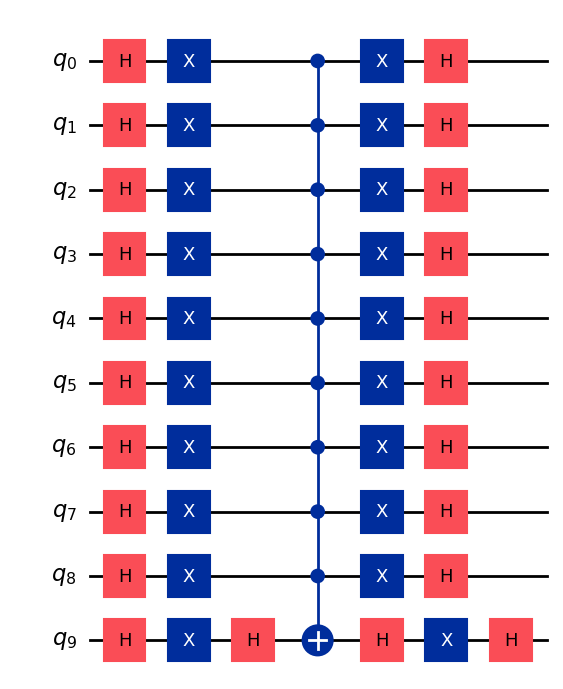

In [6]:
def build_diffuser(n_qubits: int) -> QuantumCircuit:
    """Grover diffusion operator: 2|s><s| - I"""
    qc = QuantumCircuit(n_qubits, name="Diffuser")

    qc.h(range(n_qubits))       # H⊗n
    qc.x(range(n_qubits))       # X⊗n  (maps |0> → |1> so MCZ fires on |0...0>)

    controls = list(range(n_qubits - 1))
    tgt_q    = n_qubits - 1
    qc.h(tgt_q)
    qc.mcx(controls, tgt_q)     # Multi-controlled X
    qc.h(tgt_q)

    qc.x(range(n_qubits))       # Uncompute X⊗n
    qc.h(range(n_qubits))       # H⊗n

    return qc

diffuser = build_diffuser(N_QUBITS)
print(f"Diffuser — depth: {diffuser.depth()}, gates: {diffuser.size()}")
diffuser.draw(output='mpl', fold=40)

---

## 3. Grover Iteration = Oracle + Diffuser

In [7]:
def build_grover_iteration(n_qubits: int, targets: list) -> QuantumCircuit:
    """One full Grover iteration: Oracle followed by Diffuser."""
    qc = QuantumCircuit(n_qubits, name="Grover_Iter")
    qc.compose(build_oracle(n_qubits, targets), inplace=True)
    qc.compose(build_diffuser(n_qubits),        inplace=True)
    return qc

---

## 4. Full Circuit Builder & Runner

In [8]:
def run_grover(n_qubits, targets, n_iterations, shots=2048):
    qr = QuantumRegister(n_qubits, 'q')
    cr = ClassicalRegister(n_qubits, 'c')
    qc = QuantumCircuit(qr, cr)

    # Equal superposition
    qc.h(range(n_qubits))
    qc.barrier()

    # Grover iterations
    grover_iter = build_grover_iteration(n_qubits, targets)
    for _ in range(n_iterations):
        qc.compose(grover_iter, inplace=True)
        qc.barrier()

    # Measure
    qc.measure(range(n_qubits), range(n_qubits))

    simulator = AerSimulator()
    result    = simulator.run(qc, shots=shots).result()
    counts    = result.get_counts()
    return counts, qc

def plot_results(counts, targets, n_iterations, shots, top_n=20):
    sorted_counts = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True)[:top_n])
    states  = list(sorted_counts.keys())
    freqs   = list(sorted_counts.values())
    total   = sum(counts.values())
    colors  = ['#e63946' if s in targets else '#457b9d' for s in states]

    fig, ax = plt.subplots(figsize=(14, 5))
    bars = ax.bar(states, freqs, color=colors, edgecolor='white', linewidth=0.5)
    for bar, freq in zip(bars, freqs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.003,
                f'{freq/total:.1%}', ha='center', va='bottom', fontsize=7)
    legend_elements = [
        Patch(facecolor='#e63946', label='Marked (target) states'),
        Patch(facecolor='#457b9d', label='Unmarked states'),
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    ax.set_title(f"Grover's Algorithm — {n_iterations} Iteration(s) | Marked: {targets}",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("Measured State")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"grover_{n_iterations}_iterations.png", dpi=150)
    plt.show()

---

## 5. Run Experiments

We test multiple iteration counts as required: **1, 3, 5, 10**, and the **optimal ~18**.


──────────────────────────────────────────────────
  Running 1 Grover iteration(s)...
    0110011010 → 23/2048 (1.12%)
    1101010001 → 18/2048 (0.88%)


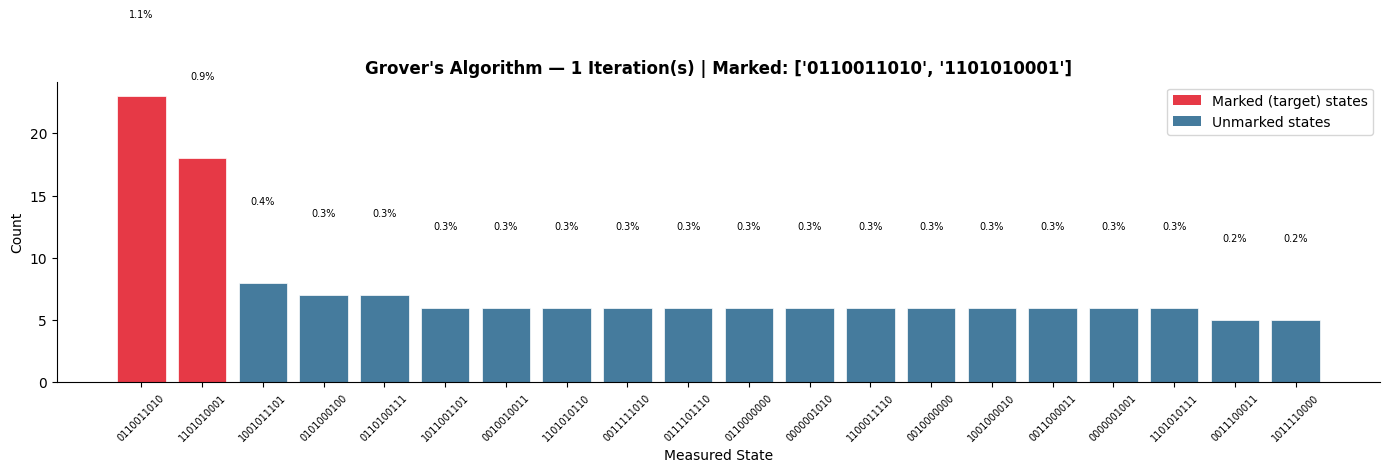


──────────────────────────────────────────────────
  Running 3 Grover iteration(s)...
    0110011010 → 91/2048 (4.44%)
    1101010001 → 106/2048 (5.18%)


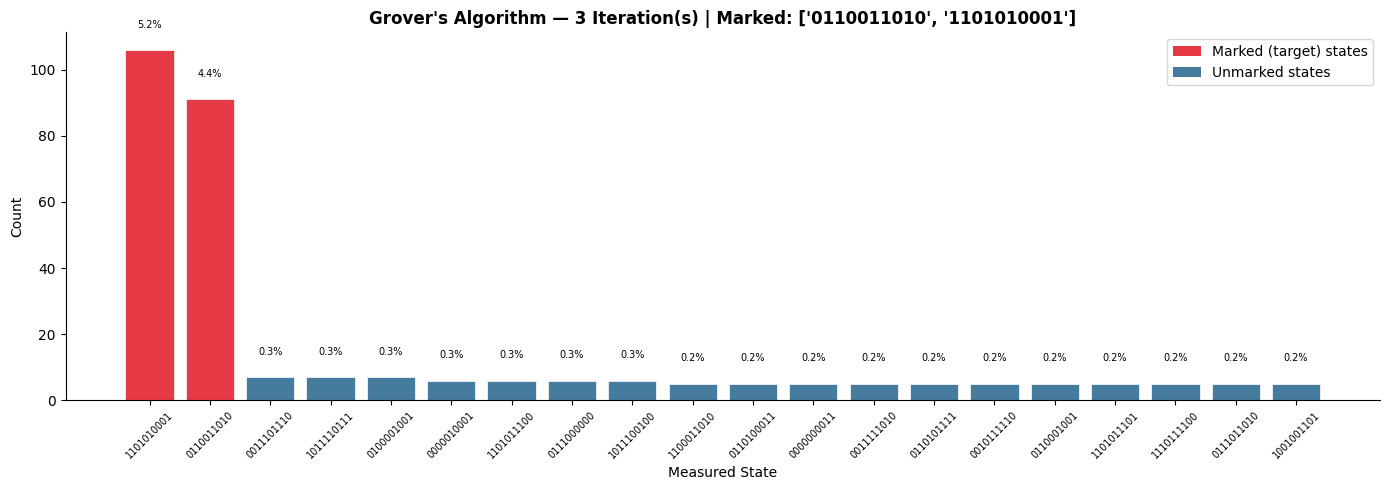


──────────────────────────────────────────────────
  Running 5 Grover iteration(s)...
    0110011010 → 224/2048 (10.94%)
    1101010001 → 240/2048 (11.72%)


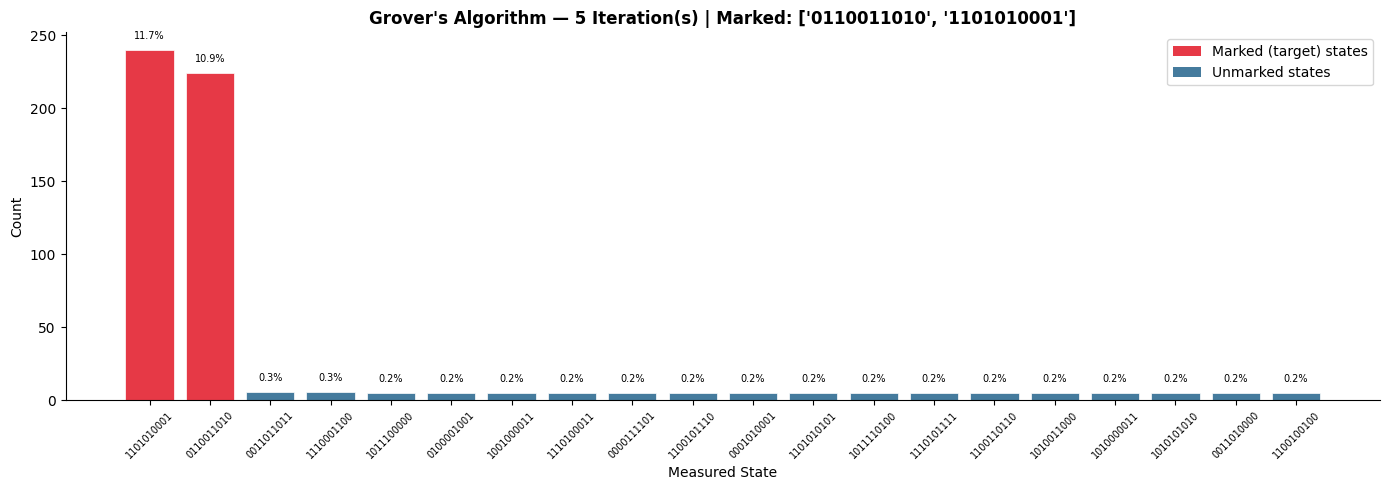


──────────────────────────────────────────────────
  Running 10 Grover iteration(s)...
    0110011010 → 661/2048 (32.28%)
    1101010001 → 639/2048 (31.20%)


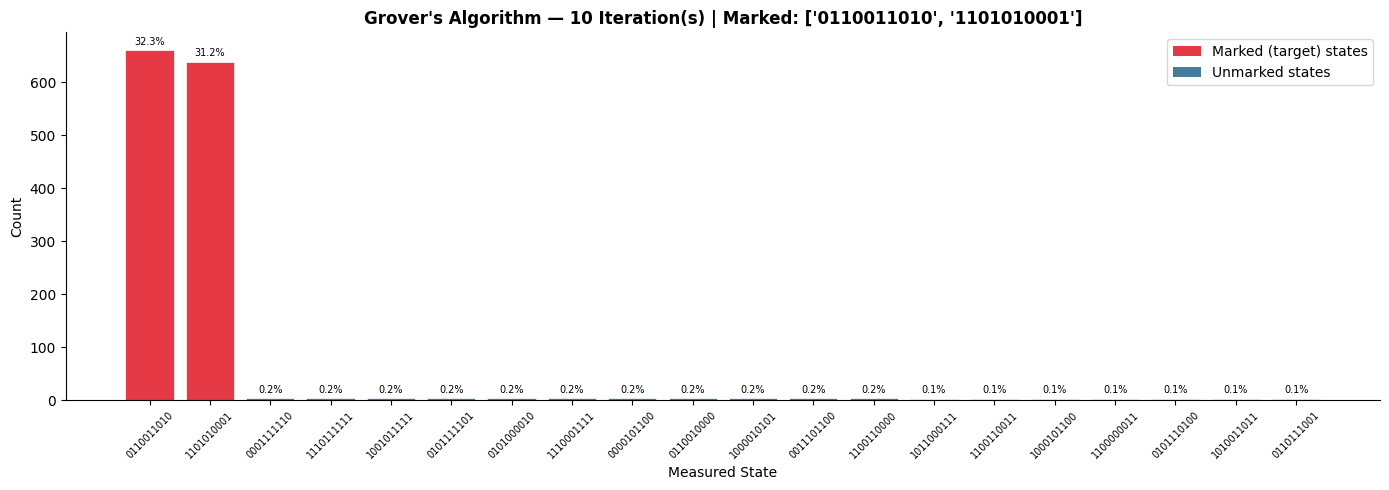


──────────────────────────────────────────────────
  Running 18 Grover iteration(s)...
    0110011010 → 1008/2048 (49.22%)
    1101010001 → 1032/2048 (50.39%)


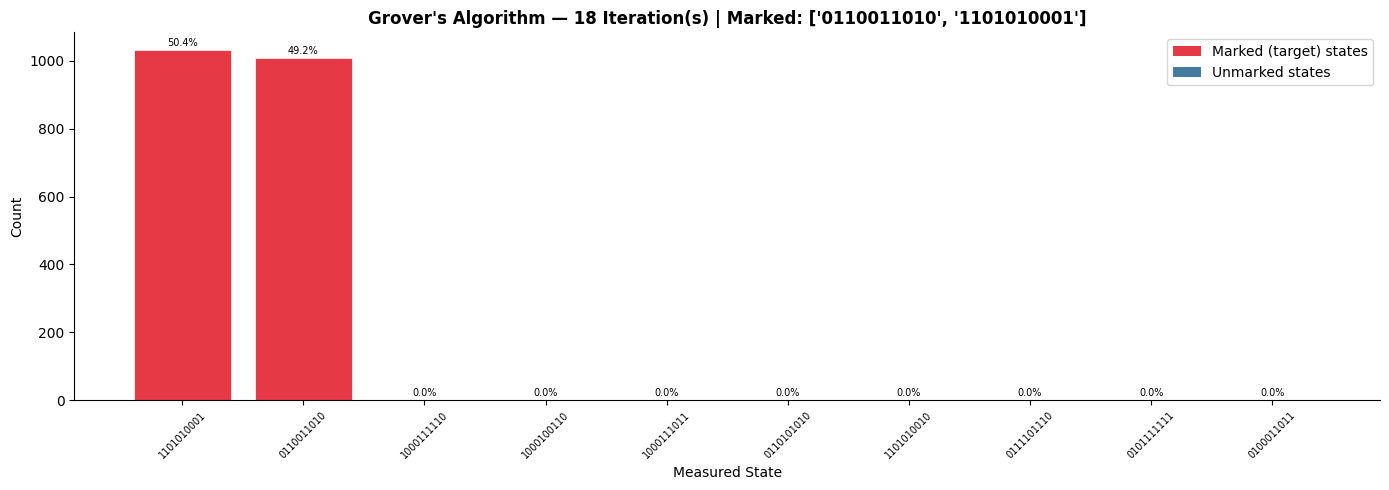

In [9]:
iteration_counts = [1, 3, 5, 10, 18]

all_results = {}
for iters in iteration_counts:
    print(f"\n{'─'*50}")
    print(f"  Running {iters} Grover iteration(s)...")
    counts, circuit = run_grover(N_QUBITS, TARGETS, iters, shots=SHOTS)
    all_results[iters] = counts

    total = sum(counts.values())
    for t in TARGETS:
        c = counts.get(t, 0)
        print(f"    {t} → {c}/{total} ({c/total:.2%})")
    plot_results(counts, TARGETS, iters, SHOTS)

---

## 6. Convergence Summary

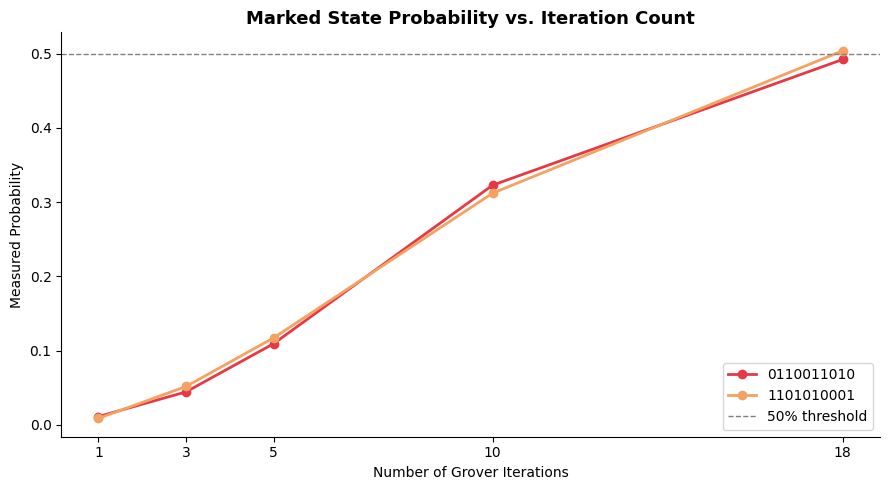

Convergence plot saved → grover_convergence.png


In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
colors_t = ['#e63946', '#f4a261']

for idx, target in enumerate(TARGETS):
    probs = []
    for iters in iteration_counts:
        total = sum(all_results[iters].values())
        c = all_results[iters].get(target, 0)
        probs.append(c / total)
    ax.plot(iteration_counts, probs, marker='o', label=target,
            color=colors_t[idx], linewidth=2)

ax.axhline(1/2, linestyle='--', color='gray', linewidth=1, label='50% threshold')
ax.set_title("Marked State Probability vs. Iteration Count",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Number of Grover Iterations")
ax.set_ylabel("Measured Probability")
ax.legend()
ax.set_xticks(iteration_counts)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig("grover_convergence.png", dpi=150)
plt.show()
print("Convergence plot saved → grover_convergence.png")